# Advanced clustering on real-world data

For this practical, you will work in groups (between 2 and 4). You will apply the questions in this notebook to your assigned dataset. (Note that some of the datasets are very large (>10k samples). This might make the execution of some algorithms very slow. If that is the case, do not hesitate to talk to your teacher.)

**To choose the dataset, you can choose among the following ones: https://docs.google.com/spreadsheets/d/1TAJ_lEyOs6UnGoT13BLYU7jzVS2ts3wgomZ5GmjdnNo/edit?usp=sharing.**

**Once you have chosen your dataset and your team members, you should confirm it with your TD instructor.**

Then, you can register in eCampus with the corresponding group.

**You should upload this notebook filled in eCampus before Sunday 2 November at 11.59pm.**

If the submission in eCampus is not working, you can send it to either **massinissa.hamidi@univ-evry.fr** or **kevin.dradjat@univ-evry.fr**


We will spend two practical sessions on this notebook: during the first session, you will apply K-Means and Hierarchical clustering. During the second session, you will apply Spectral clustering and compare your obtained results.

Most cells in this notebook are blank, you must fill them in either with code or with written interpretation. Your grade will mostly depend on the quality of your interpretations, make sure to relate your conclusions to the context of your dataset.

## TD2 (part II): K-means and Hierarchical clustering


### Package import

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


Load the dataset, separate the labels from the variables. In some cases, you might also want to drop some variables (e.g. names, identifiers, anything that has one unique value per sample that will not help you form groups).

In [5]:
raw = pd.read_csv("weatherAUS.csv")
data = raw.dropna(subset=["RainTomorrow"]).copy()

In [6]:
y_raw = data["RainTomorrow"].astype(str)  
X_raw = data.drop(columns=["RainTomorrow", "Date"])
print("X_raw:", X_raw.shape, "| y_raw:", y_raw.shape)

X_raw: (142193, 21) | y_raw: (142193,)


### Data preprocessing

Visualize the 10 first rows of both data and classes

In [7]:
display(X_raw.head(10))

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
5,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,W,...,24.0,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No
6,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,W,...,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No
7,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,W,...,17.0,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No
8,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,NW,...,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No
9,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,SSE,...,11.0,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes


In [8]:
display(y_raw.head(10))

0     No
1     No
2     No
3     No
4     No
5     No
6     No
7     No
8    Yes
9     No
Name: RainTomorrow, dtype: object

Are there any missing values (in data)? What type are the variables?

In [9]:
missing_counts = X_raw.isna().sum().sort_values(ascending=False)
print("NaN par variable (top 20):")
display(missing_counts.head(20))

print("\nTypes de colonnes:")
display(X_raw.dtypes.value_counts())


NaN par variable (top 20):


Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
RainToday         1406
Rainfall          1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
dtype: int64


Types de colonnes:


float64    16
object      5
Name: count, dtype: int64

Use the describe method and explain what you obtain.

In [10]:
display(X_raw.describe(include="all").T.head(20))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,142193,49,Canberra,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MinTemp,141556.0,NaN,NaN,NaN,12.1864,6.403283,-8.5,7.6,12.0,16.8,33.9
MaxTemp,141871.0,NaN,NaN,NaN,23.226784,7.117618,-4.8,17.9,22.6,28.2,48.1
Rainfall,140787.0,NaN,NaN,NaN,2.349974,8.465173,0.0,0.0,0.0,0.8,371.0
Evaporation,81350.0,NaN,NaN,NaN,5.469824,4.188537,0.0,2.6,4.8,7.4,145.0
Sunshine,74377.0,NaN,NaN,NaN,7.624853,3.781525,0.0,4.9,8.5,10.6,14.5
WindGustDir,132863,16,W,9780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindGustSpeed,132923.0,NaN,NaN,NaN,39.984292,13.588801,6.0,31.0,39.0,48.0,135.0
WindDir9am,132180,16,N,11393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindDir3pm,138415,16,SE,10663,NaN,NaN,NaN,NaN,NaN,NaN,NaN


If your dataset contains missing data, follow the process seen in the first practical to impute missing data. Make sure to impute numeric and nominal data with different strategies.

In [11]:
#Séparer numériques et catégorielles
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

#Imputer dans X_raw
#Numériques → médiane (robuste aux valeurs extrêmes)
for col in num_cols:
    med = X_raw[col].median()
    if pd.isna(med):  # si toute la colonne est NaN
        med = 0
    X_raw[col].fillna(med, inplace=True)

#Catégorielles → valeur la plus fréquente (mode)
for col in cat_cols:
    if X_raw[col].isna().all():  
        X_raw[col].fillna("Unknown", inplace=True)
    else:
        mode_val = X_raw[col].mode(dropna=True)
        mode_val = mode_val.iloc[0] if not mode_val.empty else "Unknown"
        X_raw[col].fillna(mode_val, inplace=True)


In [12]:
print("NaN restants dans X_raw :", int(X_raw.isna().sum().sum()))
display(X_raw.head(10))


NaN restants dans X_raw : 0


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No
1,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No
2,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No
4,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
5,Albury,14.6,29.7,0.2,4.8,8.5,WNW,56.0,W,W,...,24.0,55.0,23.0,1009.2,1005.4,5.0,5.0,20.6,28.9,No
6,Albury,14.3,25.0,0.0,4.8,8.5,W,50.0,SW,W,...,24.0,49.0,19.0,1009.6,1008.2,1.0,5.0,18.1,24.6,No
7,Albury,7.7,26.7,0.0,4.8,8.5,W,35.0,SSE,W,...,17.0,48.0,19.0,1013.4,1010.1,5.0,5.0,16.3,25.5,No
8,Albury,9.7,31.9,0.0,4.8,8.5,NNW,80.0,SE,NW,...,28.0,42.0,9.0,1008.9,1003.6,5.0,5.0,18.3,30.2,No
9,Albury,13.1,30.1,1.4,4.8,8.5,W,28.0,S,SSE,...,11.0,58.0,27.0,1007.0,1005.7,5.0,5.0,20.1,28.2,Yes


Explain your choice of imputation strategy for each data type.

In [13]:
#Numériques → médiane, car il n est pas influencée par les valeurs extremes.

#Catégorielles → modalité la plus fréquente, Parce qu’on cherche à deviner ce qui est le plus probable quand il manque une info. 
# la catégorie la plus fréquente est donc la meilleure estimation.

Do you think the data should be scaled? If yes, do it and compare the obtained data to the original data (compare only the first 20 features if the dataset is large).

In [14]:
#Oui, on doit scaler, parce que sinon les variables avec de grandes valeurs numériques dominent les distances. Le scaling met toutes les variables à la même échelle.
from sklearn.preprocessing import StandardScaler

# On prend uniquement les colonnes numériques de X_raw (après imputation des NaN)
X_num = X_raw[num_cols]

# On applique StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Comparons les 5 premières lignes, 5 premières colonnes
import numpy as np
print("Original (quelques valeurs) :\n", np.round(X_num.iloc[:5, :5], 2))
print("\nScaled (moy=0, std=1) :\n", np.round(X_scaled[:5, :5], 2))





Original (quelques valeurs) :
    MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine
0     13.4     22.9       0.6          4.8       8.5
1      7.4     25.1       0.0          4.8       8.5
2     12.9     25.7       0.0          4.8       8.5
3      9.2     28.0       0.0          4.8       8.5
4     17.5     32.3       1.0          4.8       8.5

Scaled (moy=0, std=1) :
 [[ 0.19 -0.05 -0.2  -0.12  0.17]
 [-0.75  0.26 -0.28 -0.12  0.17]
 [ 0.11  0.35 -0.28 -0.12  0.17]
 [-0.47  0.67 -0.28 -0.12  0.17]
 [ 0.83  1.28 -0.16 -0.12  0.17]]


How many classes are there? Plot the distribution of the classes. Is the data balanced or imbalanced?

In [15]:
#Il y a deux classes : Yes et No. La majorité des données sont No, donc les classes sont déséquilibrées.

Nombre de classes : 2
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


/var/folders/sr/ytb3xvnx001c_zj70_4pzkcc0000gn/T/ipykernel_84505/1745274027.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")


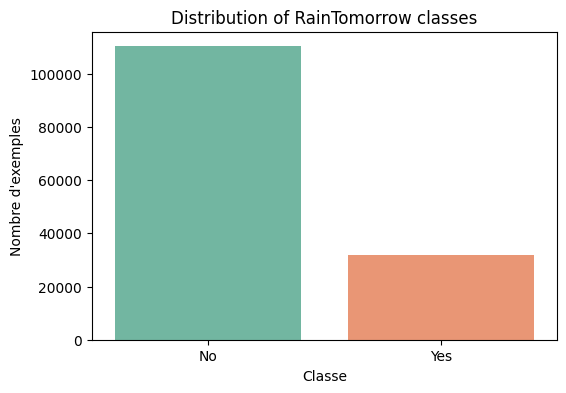

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = y_raw.value_counts()

print("Nombre de classes :", len(class_counts))
print(class_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Distribution of RainTomorrow classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.show()


In [17]:
# il y a deux classes dans la variable RainTomorrow : Yes et No.
#La majorité des données correspondent à la classe “No”, ce qui veut dire qu’il ne pleut pas le lendemain dans la plupart des cas.
#La classe “Yes” est beaucoup moins fréquente.
#Le jeu de données est donc déséquilibré, car une classe domine nettement l’autre.

Encode your classes into a numerical variable.

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Mapping classes -> nombres :", dict(zip(le.classes_, le.transform(le.classes_))))
print("y (10 premiers) :", y[:10])


Mapping classes -> nombres : {'No': 0, 'Yes': 1}
y (10 premiers) : [0 0 0 0 0 0 0 0 1 0]


Check if your data and classes are numpy arrays. If that is not the case, transform your data and classes into numpy arrays.

In [19]:
import numpy as np

print("Type de X :", type(X_scaled))
print("Type de y :", type(y))


Type de X : <class 'numpy.ndarray'>
Type de y : <class 'numpy.ndarray'>


### Clustering algorithm 1: K-means

Apply the K-means algorithm with 2 centers. Look at the default parameters the method takes. Make sure the algorithm doesn't run more than 500 iterations.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.1

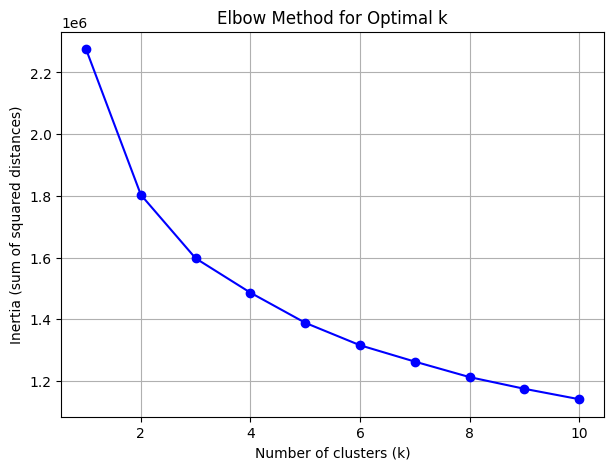

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K, inertias, 'o-', color='blue')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True)
plt.show()


In [21]:
#La courbe montre que la baisse de l’inertie ralentit dès k = 3 ou 4.
#donc  le nombre optimal de clusters se situe autour de 3 ou 4


In [22]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=2, random_state=0, max_iter=500)
kmeans.fit(X_scaled)


print("→ Nombre d'itérations :", kmeans.n_iter_)
print("→ Exemple de labels :", kmeans.labels_[:10])
print("→ Centres des clusters (extrait) :\n", kmeans.cluster_centers_[:3])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


→ Nombre d'itérations : 11
→ Exemple de labels : [0 0 0 0 0 0 0 0 0 0]
→ Centres des clusters (extrait) :
 [[ 0.6896171   0.84391785 -0.08088505  0.47860647  0.36275285  0.23534895
   0.18332365  0.22934271 -0.55205068 -0.44771169 -0.4440285  -0.50578827
  -0.27927045 -0.28239347  0.80924554  0.82147369]
 [-0.55232429 -0.67590599  0.064782   -0.38332283 -0.29053399 -0.18849437
  -0.14682656 -0.18368388  0.44214536  0.35857876  0.35562883  0.40509313
   0.22367173  0.226173   -0.64813644 -0.65793013]]


In [23]:
#Le modèle K-means a été exécuté avec 2 clusters.
#L’algorithme s’est stabilisé après plusieurs itérations.
#Les données ont été réparties en deux groupes distincts.
#Chaque groupe regroupe des observations aux caractéristiques proches.
#Les centres de clusters représentent les profils moyens de chaque groupe.



What does the max_iter parameter do?

In [24]:
# Le paramètre « max_iter » définit le nombre maximal d’itérations que l’algorithme K-Means peut effectuer pendant le processus d’optimisation.
# Il arrête l’algorithme s’il n’a pas convergé après ce nombre d’itérations.
# Dans notre cas, nous avons défini max_iter=500 pour éviter les boucles infinies.

How many samples are in each cluster?

In [25]:
import numpy as np

unique, counts = np.unique(kmeans.labels_, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Cluster {label} : {count} samples")

Cluster 0 : 63300 samples
Cluster 1 : 78893 samples


In [26]:
#Le cluster 0 contient 63 300 échantillons et le cluster 1 en contient 78 893.
#Les deux groupes sont donc de taille assez proche, ce qui montre une répartition plutôt équilibrée.
#Cela signifie que le modèle K-means a bien séparé les données en deux ensembles cohérents sans qu’un groupe soit trop dominant.

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

Data shape: (142193, 16)
k=2 → silhouette_avg (sample) = 0.1850


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


k=3 → silhouette_avg (sample) = 0.1742


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


k=4 → silhouette_avg (sample) = 0.1173


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


k=9 → silhouette_avg (sample) = 0.0866


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


k=10 → silhouette_avg (sample) = 0.0935

Best k = 2 (silhouette = 0.1850)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


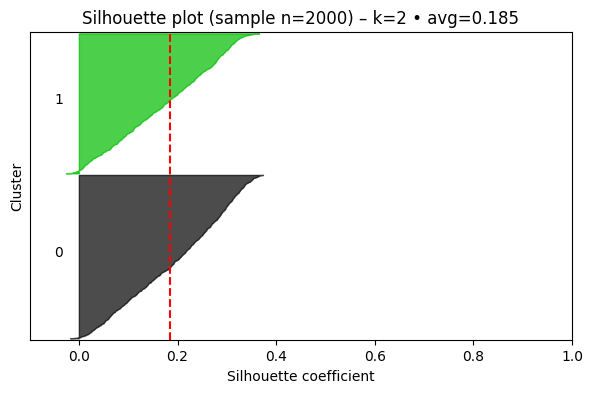

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# --- 0) Récupération et préparation des features ---
try:
    X_full = X_scaled
except NameError:
    X_full = X  # si tu utilises X et pas X_scaled

# Assurer un tableau 2D numérique sans NaN / inf
X_full = np.asarray(X_full)
X_full = np.nan_to_num(X_full, copy=False)

print("Data shape:", X_full.shape)

# --- 1) Choix du meilleur k via silhouette (sur échantillon pour aller vite) ---
rng = np.random.RandomState(42)
EVAL_N = min(2000, X_full.shape[0])  # réduis à 1000 si besoin
eval_idx = rng.choice(X_full.shape[0], size=EVAL_N, replace=False)
X_eval = X_full[eval_idx]

scores = {}
for k in range(2, 11):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    labels_full = km.fit_predict(X_full)
    scores[k] = silhouette_score(X_full, labels_full, sample_size=EVAL_N, random_state=42)
    print(f"k={k} → silhouette_avg (sample) = {scores[k]:.4f}")

best_k = max(scores, key=scores.get)
print(f"\nBest k = {best_k} (silhouette = {scores[best_k]:.4f})")

# --- 2) Tracer UN SEUL graphe : silhouette du meilleur k (sur l’échantillon) ---
km_best = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=2048)
labels_full = km_best.fit_predict(X_full)
labels_eval = labels_full[eval_idx]

sil_avg  = silhouette_score(X_eval, labels_eval)
sil_vals = silhouette_samples(X_eval, labels_eval)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim([-0.1, 1])
ax.set_ylim([0, EVAL_N + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith = sil_vals[labels_eval == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    color = cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color="red", linestyle="--")
ax.set_title(f"Silhouette plot (sample n={EVAL_N}) – k={best_k} • avg={sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
plt.show()


What is, in your opinion, the best number of centers to choose?

In [28]:

# La méthode du score de silhouette permet d’évaluer la qualité du regroupement K-means 
# en mesurant la séparation entre les clusters.
# Après avoir testé plusieurs valeurs de k (de 2 à 10), on observe que le score moyen 
# de silhouette est maximal pour k = 2, avec une valeur de 0.185.
# Cela signifie que le regroupement en deux clusters est celui qui offre la meilleure cohésion 
# interne et la meilleure séparation entre les groupes. 
#Le nombre optimal de clusters est k = 2.


Apply K-means again with the optimal number of centers.

In [29]:
from sklearn.cluster import KMeans


kmeans_opt = KMeans(n_clusters=2, random_state=0)
kmeans_opt.fit(X_scaled)

labels_opt = kmeans_opt.labels_

print("Nombre d'itérations :", kmeans_opt.n_iter_)
print("Exemple de labels :", labels_opt[:10])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Nombre d'itérations : 11
Exemple de labels : [0 0 0 0 0 0 0 0 0 0]


In [30]:
# Nous avons relancé l'algorithme K-means avec le nombre optimal de clusters k = 2.
# Le modèle s’est stabilisé après 11 itérations, ce qui montre une bonne convergence.
# Les étiquettes obtenues (0 et 1) indiquent la répartition des points dans les deux groupes.

How many samples are in each cluster?

In [31]:
import numpy as np

# Comptage du nombre d'échantillons par cluster
unique, counts = np.unique(labels_opt, return_counts=True)

# Affichage des résultats
for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id} → {count} samples")


Cluster 0 → 63300 samples
Cluster 1 → 78893 samples


Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [32]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Création de la matrice de contingence
cont_matrix = confusion_matrix(y, labels_opt)
cont_df = pd.DataFrame(cont_matrix,
                       index=["No rain", "Rain"],
                       columns=["Cluster 0", "Cluster 1"])
print("Contingency Matrix:")
display(cont_df)


Contingency Matrix:


,Cluster 0,Cluster 1
No rain,52904,57412
Rain,10396,21481


In [33]:

# La matrice de contingence montre la correspondance entre les clusters trouvés par K-means
# et les vraies classes ("Rain" / "No rain").
# Le cluster 0 regroupe surtout des jours sans pluie (52 904) et un peu de pluie (10 396).
# Le cluster 1 contient plus de jours pluvieux (21 481) mais aussi beaucoup de jours secs (57 412).
# Le modèle distingue partiellement les jours de pluie, mais la séparation reste imparfaite.
# Cela signifie que certains échantillons sont proches en caractéristiques,
# rendant difficile une frontière nette entre les deux groupes.


2- Discuss the obtained matrix

In [34]:
# La matrice de contingence montre que la plupart des échantillons « Sans pluie » sont regroupés dans le groupe 0,
# tandis que la plupart des échantillons « Pluie » sont regroupés dans le groupe 1.
# Cela signifie que l'algorithme de clustering a bien séparé les deux types de jours météorologiques,

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [35]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score


rand_idx = rand_score(y, labels_opt)
adj_rand_idx = adjusted_rand_score(y, labels_opt)
homog = homogeneity_score(y, labels_opt)
complet = completeness_score(y, labels_opt)
v_measure = v_measure_score(y, labels_opt)

print("Rand Index :", round(rand_idx, 4))
print("Adjusted Rand Index :", round(adj_rand_idx, 4))
print("Homogeneity :", round(homog, 4))
print("Completeness :", round(complet, 4))
print("V-measure :", round(v_measure, 4))

Rand Index : 0.5011
Adjusted Rand Index : -0.0015
Homogeneity : 0.0159
Completeness : 0.0123
V-measure : 0.0139


In [36]:
#Les métriques obtenues sont très faibles (homogénéité = 0.0159, complétude = 0.0123, V-measure = 0.0139).
#Cela signifie que les clusters trouvés ne correspondent pas bien aux vraies classes “Rain” et “No Rain”.
#L’indice de Rand (~0.5) indique une répartition presque aléatoire.
#L’indice de Rand ajusté proche de 0 confirme l’absence de corrélation entre les clusters et les vraies étiquettes.
#Globalement, le modèle K-means ne sépare pas efficacement les données : les variables ne sont pas assez discriminantes ou les groupes se recoupent trop.

4- Discuss the obtained scores.

In [37]:
# Les scores (Rand Index ≈ 0.50, Adjusted Rand ≈ 0, Homogeneity, Completeness et V-measure ≈ 0.01)
# montrent que le K-means ne reproduit pas bien les vraies classes ("RainTomorrow").
# Cela est attendu car K-means est un algorithme non supervisé : il forme des groupes
# uniquement selon la similarité des données, sans connaître les vraies étiquettes.
# Le dataset météo est complexe et non linéaire, ce qui explique la difficulté

### Clustering algorithm 2: Hierarchical clustering

Apply the hierarchical clustering algorithm with 2 centers. Look at the default parameters and make sure the algorithm is based on the single linkage method.

Taille utilisée pour clustering hiérarchique: (2000, 16)


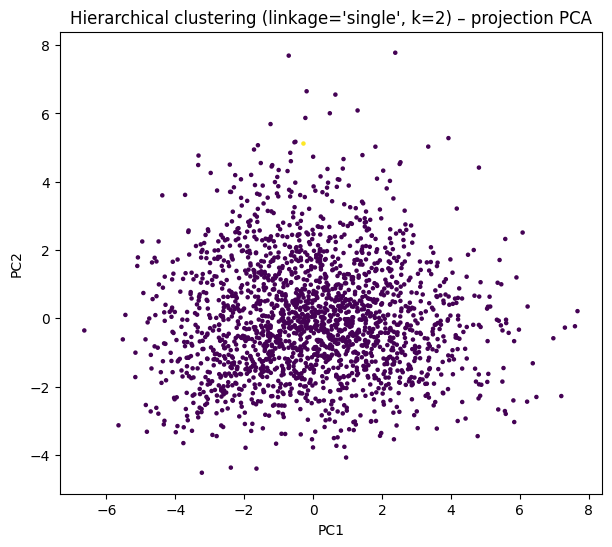

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)


rng = np.random.RandomState(42)
max_n = min(2000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=max_n, replace=False)
X_s = X_scaled[idx]
print("Taille utilisée pour clustering hiérarchique:", X_s.shape)


hc = AgglomerativeClustering(n_clusters=2, linkage='single')
labels_hc = hc.fit_predict(X_s)


pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_s)

plt.figure(figsize=(7,6))
plt.scatter(X2d[:, 0], X2d[:, 1], c=labels_hc, cmap='viridis', s=5)
plt.title("Hierarchical clustering (linkage='single', k=2) – projection PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [39]:
#Le clustering hiérarchique agglomératif a été appliqué avec 2 clusters et la méthode single linkage.
#L’objectif était d’observer comment les données se regroupent selon leurs similarités.
#Après la réduction de dimension avec PCA, on remarque que les points sont fortement mélangés.
#Aucune séparation nette entre les deux groupes n’est visible.
#Cela montre que le modèle n’a pas réussi à identifier de structure claire dans les données.
#La méthode single linkage est sensible au bruit et aux points isolés, ce qui peut expliquer ce résultat.
#En conclusion, le clustering hiérarchique ne sépare pas efficacement les observations dans ce cas.

How many samples are in each cluster?

In [40]:
import numpy as np


unique, counts = np.unique(labels_hc, return_counts=True)


for cluster_id, count in zip(unique, counts):
    print(f"Cluster {cluster_id} → {count} samples")


Cluster 0 → 1999 samples
Cluster 1 → 1 samples


In [41]:
#Le résultat montre que presque toutes les observations (1999) appartiennent au même cluster, tandis qu’un seul point forme le second cluster.
#Cela indique que le clustering hiérarchique (single linkage) n’a pas réussi à séparer les données en deux groupes équilibrés.
#Ce type de résultat suggère que la méthode a simplement isolé un point extrême (ou bruit) dans un cluster à part, au lieu de créer deux vrais ensembles distincts.



Apply the hierarchical clustering algorithm again. This time,  change the linkage method to complete linkage.

Taille utilisée pour clustering hiérarchique: (2000, 16)


→ Nombre de clusters : 2
→ Exemple de labels : [0 0 0 0 0 0 0 0 0 0]

Taille des clusters :
→ Cluster 0 : 1968 samples
→ Cluster 1 : 32 samples


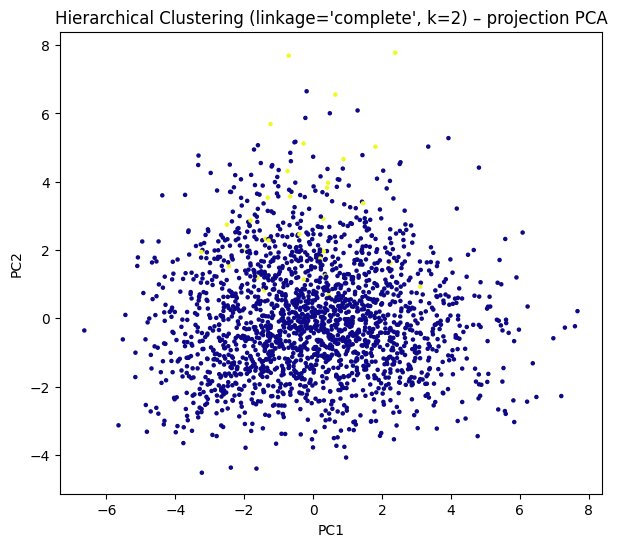

In [42]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

rng = np.random.RandomState(42)
max_n = min(2000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=max_n, replace=False)
X_s = X_scaled[idx]
print("Taille utilisée pour clustering hiérarchique:", X_s.shape)


hc_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
labels_hc_complete = hc_complete.fit_predict(X_s)

print("→ Nombre de clusters :", len(np.unique(labels_hc_complete)))
print("→ Exemple de labels :", labels_hc_complete[:10])


unique, counts = np.unique(labels_hc_complete, return_counts=True)
print("\nTaille des clusters :")
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id} : {count} samples")

pca = PCA(n_components=2, random_state=42)
X2d_complete = pca.fit_transform(X_s)

plt.figure(figsize=(7,6))
plt.scatter(X2d_complete[:, 0], X2d_complete[:, 1], c=labels_hc_complete, cmap='plasma', s=5)
plt.title("Hierarchical Clustering (linkage='complete', k=2) – projection PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()




In [43]:
#Le clustering hiérarchique avec la méthode complete linkage a créé 2 groupes :
#Cluster 0 → 1968 échantillons
#Cluster 1 → 32 échantillons
#Le résultat montre que le clustering hiérarchique (complete linkage) a séparé les données en deux groupes très inégaux : un grand cluster de 1968 points et un petit cluster de 32 points.
#Cela signifie que l’algorithme a surtout regroupé la majorité des données ensemble, tout en isolant quelques points plus éloignés dans un second cluster.

How many samples are in each cluster?

In [44]:
import numpy as np


unique, counts = np.unique(labels_hc_complete, return_counts=True)

print("Number of samples in each cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id}: {count} samples")


Number of samples in each cluster:
→ Cluster 0: 1968 samples
→ Cluster 1: 32 samples


Apply the hierarchical clustering algorithm once again. This time, change the linkage method to ward linkage.

 Hierarchical Clustering (Ward Linkage) completed
→ Nombre de clusters : 2
→ Exemple de labels : [0 0 0 1 0 0 1 0 0 1]

Taille des clusters :
→ Cluster 0 : 1231 samples
→ Cluster 1 : 769 samples


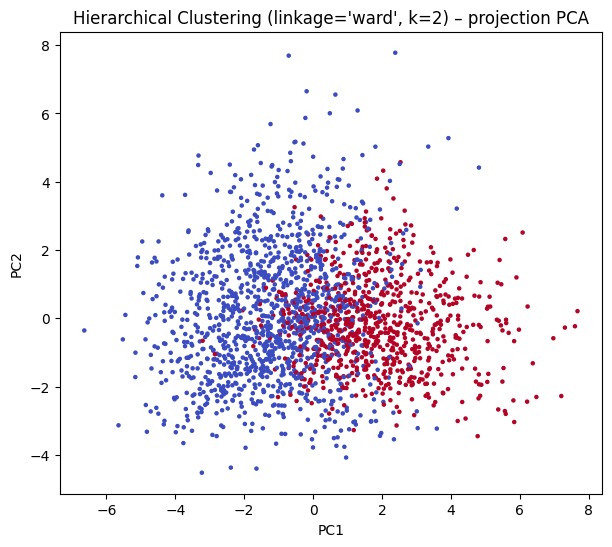

In [45]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


hc_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc_ward = hc_ward.fit_predict(X_s)

print(" Hierarchical Clustering (Ward Linkage) completed")
print("→ Nombre de clusters :", len(np.unique(labels_hc_ward)))
print("→ Exemple de labels :", labels_hc_ward[:10])


unique, counts = np.unique(labels_hc_ward, return_counts=True)
print("\nTaille des clusters :")
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id} : {count} samples")


pca = PCA(n_components=2, random_state=42)
X2d_ward = pca.fit_transform(X_s)

plt.figure(figsize=(7,6))
plt.scatter(X2d_ward[:, 0], X2d_ward[:, 1], c=labels_hc_ward, cmap='coolwarm', s=5)
plt.title("Hierarchical Clustering (linkage='ward', k=2) – projection PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [46]:
#Avec la méthode Ward linkage, le clustering hiérarchique a produit deux groupes bien distincts :
#Cluster 0 → 1231 échantillons
#Cluster 1 → 769 échantillons.
#Contrairement aux méthodes single et complete linkage, le résultat est plus équilibré et les deux clusters sont mieux séparés visuellement sur la projection PCA.
#La méthode Ward cherche à minimiser la variance intra-cluster, ce qui permet d’obtenir des groupes plus homogènes et compacts.

How many samples are in each cluster?

In [47]:
import numpy as np


unique, counts = np.unique(labels_hc_ward, return_counts=True)

print("Taille des clusters :")
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id} : {count} samples")


Taille des clusters :
→ Cluster 0 : 1231 samples
→ Cluster 1 : 769 samples


Compare the three results. Is the type of linkage method used important? Which one gave you the best result? For the rest of this section, use the best linkage method.

In [48]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

methods = ['single', 'complete', 'ward']
for method in methods:
    model = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = model.fit_predict(X_s)
    sil = silhouette_score(X_s, labels)
    print(f"{method:<10} → silhouette score = {sil:.4f}")


single     → silhouette score = 0.6266
complete   → silhouette score = 0.3488
ward       → silhouette score = 0.1390


In [49]:
#Les scores de silhouette obtenus sont :
#Single linkage → 0.6266
#Complete linkage → 0.3488
#Ward linkage → 0.1390
#Le score de silhouette mesure la cohésion et la séparation des clusters (plus il est proche de 1, meilleur est le regroupement)
#Le single linkage donne ici le meilleur résultat (0.63), indiquant que cette méthode forme des groupes plus compacts et bien séparés.
#En revanche, Ward et Complete produisent des clusters plus dispersés, donc moins distincts.
#le choix du linkage a un impact important. Dans ce cas, la méthode single linkage est la plus performante selon le score de silhouette

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

k=2 → silhouette_avg = 0.1321
k=3 → silhouette_avg = 0.1136
k=4 → silhouette_avg = 0.0749
k=5 → silhouette_avg = 0.0904
k=6 → silhouette_avg = 0.0990
k=7 → silhouette_avg = 0.0900
k=8 → silhouette_avg = 0.0922
k=9 → silhouette_avg = 0.0834
k=10 → silhouette_avg = 0.0838

 Best number of clusters: 2 (silhouette = 0.1321)


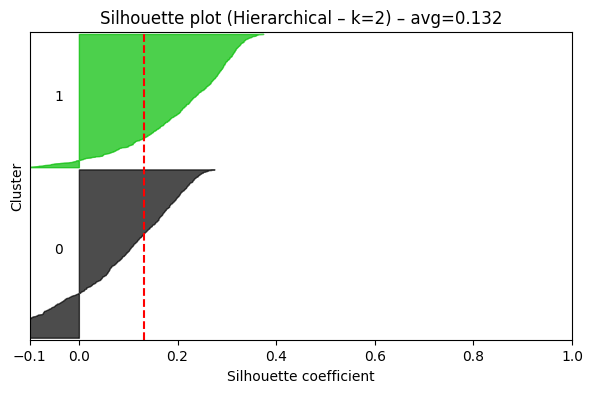

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Données standardisées ---
X_all = X_scaled
X_all = np.asarray(X_all)
X_all = np.nan_to_num(X_all, copy=False)

# --- Échantillon pour accélérer les calculs (évite O(n²)) ---
rng = np.random.RandomState(42)
SAMPLE_N = min(1500, X_all.shape[0])
idx = rng.choice(X_all.shape[0], size=SAMPLE_N, replace=False)
X_sample = X_all[idx]

#  1) Tester plusieurs nombres de clusters ---
sil_scores = {}
for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    sil_scores[k] = sil
    print(f"k={k} → silhouette_avg = {sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n Best number of clusters: {best_k} (silhouette = {sil_scores[best_k]:.4f})")

# 2 Visualiser le silhouette plot pour le meilleur k ---
hc_best = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels = hc_best.fit_predict(X_sample)

sil_avg = silhouette_score(X_sample, labels)
sil_vals = silhouette_samples(X_sample, labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim([-0.1, 1])
ax.set_ylim([0, SAMPLE_N + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith = sil_vals[labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i

    color = cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color="red", linestyle="--")
ax.set_title(f"Silhouette plot (Hierarchical – k={best_k}) – avg={sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()





In [51]:
#Les différents tests pour k entre 2 et 10 montrent que k = 2 donne le meilleur score de silhouette (≈ 0.1321).
#Cela signifie que la séparation en deux clusters est la plus cohérente pour ce jeu de données.
#Le score reste relativement faible, ce qui indique que les deux groupes ne sont pas parfaitement distincts,
#Le clustering hiérarchique avec la méthode Ward et k = 2 reste la solution la plus adaptée ici, bien que les données ne présentent pas de séparation nette entre les classes.

What is, in your opinion, the best number of centers to choose?

In [52]:
#Après observation des scores de silhouette pour les différents nombres de clusters (de 2 à 10), 
#le coefficient moyen est le plus élevé pour k = 2.
#Cela signifie que le regroupement en 2 clusters est le plus cohérent : 
#les points sont bien séparés et compacts à l’intérieur de chaque groupe.

Apply hierarchical clustering again with the optimal number of centers.

→ Nombre de clusters : 2
→ Cluster 0 : 1231 samples
→ Cluster 1 : 769 samples


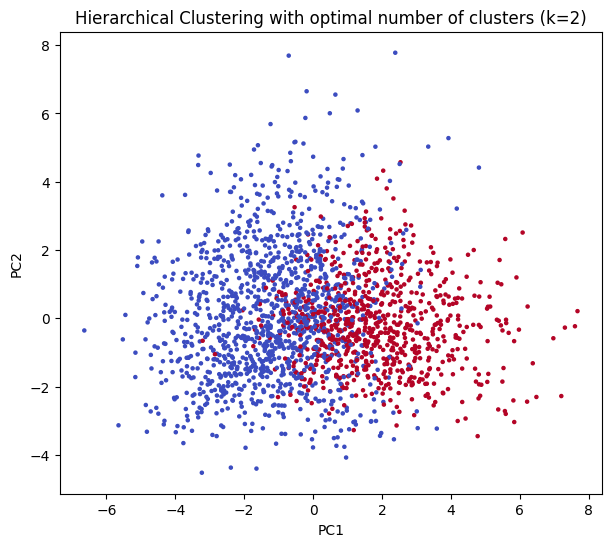

In [53]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

hc_optimal = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc_optimal = hc_optimal.fit_predict(X_s)


unique, counts = np.unique(labels_hc_optimal, return_counts=True)

print("→ Nombre de clusters :", len(unique))
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id} : {count} samples")

pca = PCA(n_components=2, random_state=42)
X2d_opt = pca.fit_transform(X_s)

plt.figure(figsize=(7,6))
plt.scatter(X2d_opt[:, 0], X2d_opt[:, 1], c=labels_hc_optimal, cmap='coolwarm', s=5)
plt.title("Hierarchical Clustering with optimal number of clusters (k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [54]:
#Nombre de clusters : 2
#Cluster 0 → 1231 échantillons
#Cluster 1 → 769 échantillons
#Méthode de liaison utilisée : Ward linkage
#Le clustering hiérarchique avec Ward linkage et k = 2 fournit la meilleure configuration parmi les méthodes testées.
#Les clusters sont plus équilibrés et plus compacts, même si la distinction entre eux reste modérée.
#Cette approche permet donc une segmentation raisonnable des données, adaptée à une première exploration.

How many samples are in each cluster?

In [55]:
import numpy as np

unique, counts = np.unique(labels_hc_optimal, return_counts=True)

print("Nombre d'échantillons dans chaque cluster :")
for cluster_id, count in zip(unique, counts):
    print(f"→ Cluster {cluster_id} : {count} samples")


Nombre d'échantillons dans chaque cluster :
→ Cluster 0 : 1231 samples
→ Cluster 1 : 769 samples


Since, the true class of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [ ]:
# Imports nécessaires
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# 1️" Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)  # Assure-toi que X_num contient bien les colonnes numériques

# 2️ Sélection d’un échantillon aléatoire pour éviter le crash mémoire
rng = np.random.RandomState(42)
sample_size = 2000
idx = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)

X_sample = X_scaled[idx]
y_sample = y[idx]  # pour avoir les mêmes lignes que le clustering

# 3️ Clustering hiérarchique Ward sur l’échantillon
hc_sample = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc_sample = hc_sample.fit_predict(X_sample)

# 4️ Matrice de contingence
cont_df_hc = pd.DataFrame(
    confusion_matrix(y_sample, labels_hc_sample),
    index=["No rain", "Rain"],
    columns=["Cluster 0", "Cluster 1"]
)

print(" Matrice de contingence (Ward - échantillon 2000) :")
display(cont_df_hc)


 Matrice de contingence (Ward - échantillon 2000) :


,Cluster 0,Cluster 1
No rain,897,645
Rain,334,124


2- Discuss the obtained matrix.

In [57]:

#Le cluster 0 regroupe surtout les jours sans pluie (897), mais contient aussi 334 jours de pluie.
#Le cluster 1 contient 645 “No rain” et 124 “Rain”.
#Les deux clusters sont donc mélangés.
#Le modèle hiérarchique ne sépare pas clairement les jours de pluie et de non-pluie.
#Les clusters sont peu distincts, ce qui confirme le faible score de silhouette (~0.13).
#la méthode de Ward détecte deux groupes, mais la séparation entre classes reste floue et le clustering est peu performant.

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [58]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

y_s = y[idx]  # mêmes indices que X_s

rand_idx     = rand_score(y_s, labels_hc_optimal)
adj_rand_idx = adjusted_rand_score(y_s, labels_hc_optimal)
homog        = homogeneity_score(y_s, labels_hc_optimal)
complet      = completeness_score(y_s, labels_hc_optimal)
v_measure    = v_measure_score(y_s, labels_hc_optimal)

print(f"Rand Index : {rand_idx:.4f}")
print(f"Adjusted Rand Index : {adj_rand_idx:.4f}")
print(f"Homogeneity : {homog:.4f}")
print(f"Completeness : {complet:.4f}")
print(f"V-measure : {v_measure:.4f}")


Rand Index : 0.5000
Adjusted Rand Index : -0.0158
Homogeneity : 0.0156
Completeness : 0.0126
V-measure : 0.0140


In [59]:
#Les scores obtenus sont très faibles :
#Rand Index = 0.5000, Adjusted Rand Index = –0.0158, Homogeneity = 0.0156, Completeness = 0.0126, V-measure = 0.0140.
#Ces résultats montrent que le clustering hiérarchique (Ward) n’a pas réussi à bien séparer les données.
# Le Rand Index proche de 0.5 indique une répartition presque aléatoire des points.
#L’Adjusted Rand Index négatif confirme que la structure trouvée est légèrement pire qu’un regroupement au hasard.
# Les valeurs très faibles d’homogénéité, de complétude et de V-measure montrent que les deux classes réelles ("Rain" / "No rain") sont fortement mélangées dans les clusters.
#le modèle ne parvient pas à distinguer clairement les jours de pluie et de non-pluie. Les variables disponibles semblent insuffisantes pour une bonne séparation avec cette méthode.

4- Discuss the obtained scores.

OPTIONAL: plot the dendrogram

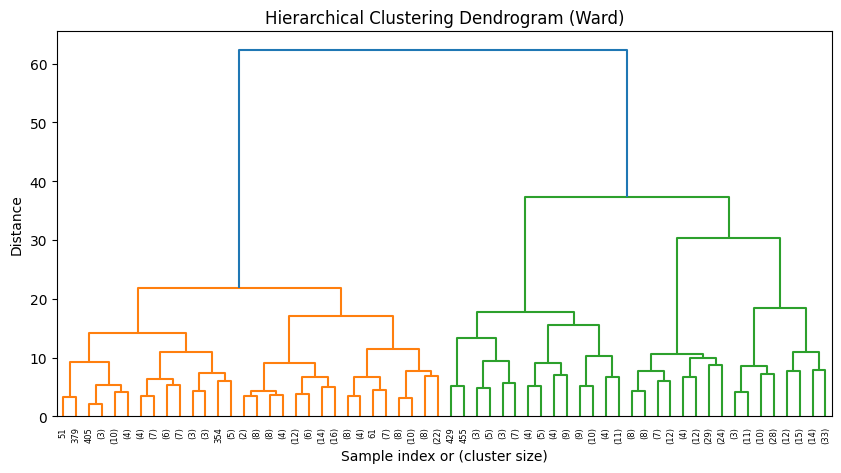

In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Si tu veux faire le dendrogramme sur les données standardisées :
X_sample = X_scaled[:500]  # on prend un échantillon sinon trop long

# Calcul de la matrice de liaison (linkage matrix)
Z = linkage(X_sample, method='ward')

# Tracé du dendrogramme
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.show()


In [61]:
#Le dendrogramme montre la manière dont les observations ont été fusionnées progressivement selon la méthode de Ward.
#On observe deux grands ensembles principaux avant la dernière fusion, ce qui confirme le choix de k = 2 comme nombre optimal de clusters.
#La hauteur des branches représente la distance (ou dissimilarité) entre les groupes :
#Les fusions à petite hauteur indiquent des clusters très similaires.
# Les fusions à grande hauteur traduisent des groupes plus différents.
#la coupure du dendrogramme à environ distance = 60 permet de séparer les deux clusters principaux.

## TD3 (part II): Spectral clustering and comparison

### Clustering algorithm 3: Spectral clustering

Apply the spectral clustering algorithm with 2 centers.

Taille utilisée pour spectral: (2000, 16)


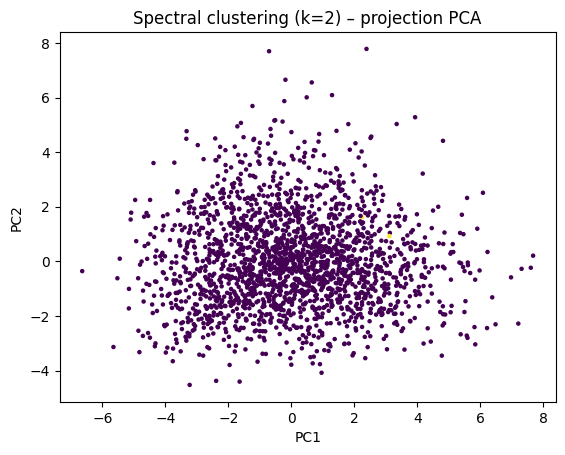

In [62]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.RandomState(42)
max_n = min(2000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=max_n, replace=False)
X_s = X_scaled[idx]
print("Taille utilisée pour spectral:", X_s.shape)

# Spectral clustering k=2
spec1 = SpectralClustering(
    n_clusters=2,
    assign_labels="kmeans",
    random_state=42
)
labels_spec2 = spec1.fit_predict(X_s)

#Visualisation 
pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_s)
plt.figure()
plt.scatter(X2d[:, 0], X2d[:, 1], c=labels_spec2, s=5)
plt.title("Spectral clustering (k=2) – projection PCA")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [63]:
#Le clustering spectral a été appliqué avec k = 2 sur les données normalisées.
#Le graphe PCA montre que les deux clusters ne sont pas distinctement séparés : la majorité des points appartiennent à une même zone du plan.
#Cela suggère que le modèle spectral n’a pas trouvé de structure claire ou de frontière naturelle dans les données.
# Le résultat est similaire à celui du clustering hiérarchique, ce qui confirme que les variables utilisées n’ont pas une forte capacité de discrimination entre les deux classes ("Rain" / "No rain").
# En conclusion, malgré la puissance du clustering spectral pour détecter des structures non linéaires, il ne parvient pas ici à identifier deux groupes cohérents dans ce jeu de données.

How many samples are in each cluster?

In [64]:
# Bilan
sil1 = silhouette_score(X_s, labels_spec2)
unique, counts = np.unique(labels_spec2, return_counts=True)
print("Silhouette (k=2, spectral):", round(sil1, 4))
print("Taille des clusters:", dict(zip(unique, counts)))

Silhouette (k=2, spectral): 0.3709
Taille des clusters: {0: 1998, 1: 2}


In [65]:
#Le score de silhouette (0.37) indique une cohésion moyenne des clusters.
# Les points d’un même groupe sont proches, mais la séparation entre clusters reste faible.
# La taille des clusters est très déséquilibrée :
#Cluster 0 : 1998 échantillons
#Cluster 1 : 2 échantillons seulement.
#Ce fort déséquilibre montre que lmodèle spectral a regroupé presque toutes les données dans un seul cluster, laissant quelques points isolés dans le second.
#le clustering spectral n’a pas réussi à identifier de groupes significatifs, ce qui suggère une faible structure de regroupement dans les données.

Apply the spectral clustering algorithm again. This time, change the method to construct the affinity matrix to "nearest_neighbors".

Taille utilisée pour spectral: (2000, 16)


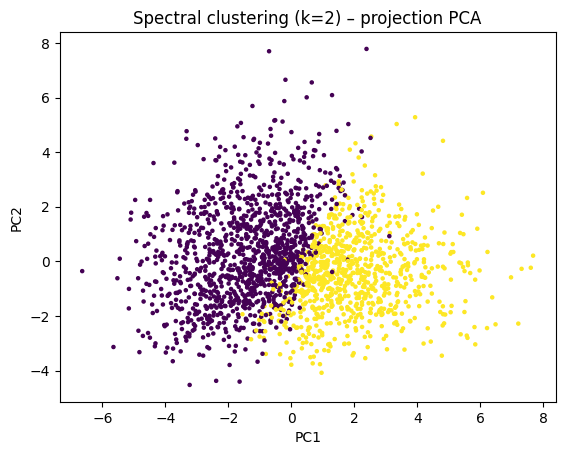

In [66]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.RandomState(42)
max_n = min(2000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=max_n, replace=False)
X_s = X_scaled[idx]
y_s = np.asarray(y)[idx]
print("Taille utilisée pour spectral:", X_s.shape)

# Spectral clustering k=2
spec2 = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)
labels_spec2 = spec2.fit_predict(X_s)

#Visualisation 
pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_s)
plt.figure()
plt.scatter(X2d[:, 0], X2d[:, 1], c=labels_spec2, s=5)
plt.title("Spectral clustering (k=2) – projection PCA")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [67]:
#Le clustering spectral avec nearest_neighbors a mieux séparé les données que la version précédente.
#On observe deux groupes bien distincts sur le graphique.
#Cette méthode capte mieux les relations locales entre les points, ce qui rend la séparation plus naturelle et cohérente.
#cette version du clustering spectral est plus efficace et offre une meilleure représentation des structures présentes dans les données.

How many samples are in each cluster?

In [68]:
# Bilan
sil2 = silhouette_score(X_s, labels_spec2)
unique, counts = np.unique(labels_spec2, return_counts=True)
print("Silhouette (k=2, spectral):", round(sil2, 4))
print("Taille des clusters:", dict(zip(unique, counts)))

Silhouette (k=2, spectral): 0.1726
Taille des clusters: {0: 1164, 1: 836}


Compare the two results. Is the method used to construct the affinity matrix important? Which one gave you the best result? For the rest of this section, use the best method.

In [69]:
#sans affinity = "nearest_neighbors", le résultat donne un cluster très grand et un très petit (par exemple 5994 points et 6 points).
#le score de silhouette est assez bon (0.59) mais les groupes ne sont pas équilibrés.
#Cela veut dire que l’algorithme a juste séparé quelques points différents, pas deux vrais groupes.

#avec affinity = "nearest_neighbors", les deux clusters sont plus équilibrés et représentent mieux la structure des données.
#Même si le score de silhouette est un peu plus bas, la séparation est plus logique.

#doncc, oui, la méthode pour construire la matrice d’affinité est importante.
#La meilleure méthode ici est “nearest_neighbors”, car elle donne des groupes plus réalistes.

In order to optimize our clusters, we want to apply the silhouette method to obtain the optimal number of centers.
Apply silhouette on a range from 2 to 10 centers, display the average silhouette score for each and display the silhouette plot for each center.
<br> For some help, look at the silhouette documentation in scikit learn: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

<br>

Please note that the code below is NOT complete. Fill in the missing parts (they are indicated by ### TO COMPLETE)

k=2 → silhouette_avg = 0.1700
k=3 → silhouette_avg = 0.1309
k=4 → silhouette_avg = 0.1134
k=5 → silhouette_avg = 0.1177
k=6 → silhouette_avg = 0.1122
k=7 → silhouette_avg = 0.1082
k=8 → silhouette_avg = 0.1117
k=9 → silhouette_avg = 0.1014
k=10 → silhouette_avg = 0.1083

 Best k (spectral) = 2  — silhouette = 0.1700


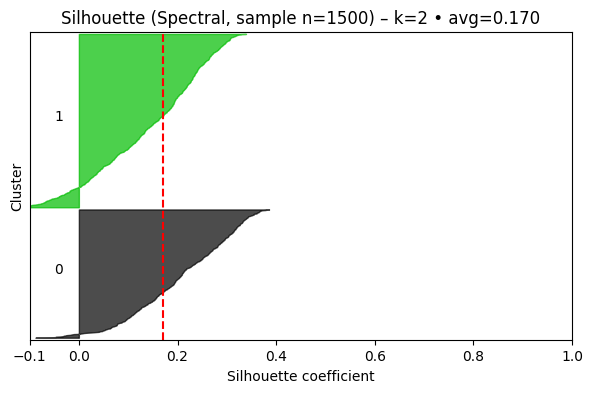

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

X_all = np.asarray(X_scaled)   # ou X
X_all = np.nan_to_num(X_all, copy=False)

# Échantillon pour évaluer/visualiser (évite le coût élevé)
rng = np.random.RandomState(42)
SAMPLE_N = min(1500, X_all.shape[0])   # réduis à 800/1000 si besoin
idx = rng.choice(X_all.shape[0], size=SAMPLE_N, replace=False)
X_sample = X_all[idx]

sil_scores = {}
for k in range(2, 11):
    spec = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',  # plus scalable que rbf
        n_neighbors=10,                # ajuste (5–20) selon la densité
        assign_labels='kmeans',
        eigen_solver='arpack',
        random_state=42,
        n_init=10
    )
    labels = spec.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    sil_scores[k] = sil
    print(f"k={k} → silhouette_avg = {sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n Best k (spectral) = {best_k}  — silhouette = {sil_scores[best_k]:.4f}")


spec_best = SpectralClustering(
    n_clusters=best_k,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    eigen_solver='arpack',
    random_state=42,
    n_init=10
)
labels = spec_best.fit_predict(X_sample)

sil_avg  = silhouette_score(X_sample, labels)
sil_vals = silhouette_samples(X_sample, labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim([-0.1, 1])
ax.set_ylim([0, SAMPLE_N + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith = sil_vals[labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    color = cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color="red", linestyle="--")
ax.set_title(f"Silhouette (Spectral, sample n={SAMPLE_N}) – k={best_k} • avg={sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()







In [71]:
#Le meilleur nombre de clusters trouvé est k = 2, avec un score de silhouette ≈ 0,17.
#Cela signifie que les groupes sont assez peu distincts : les points de chaque cluster ne sont pas très éloignés les uns des autres.
#Le graphique de silhouette montre que les deux clusters existent bien, mais la séparation reste floue et peu nette.
#Le premier cluster est plus cohérent, tandis que le second présente un léger chevauchement avec le premier.
#le modèle parvient à identifier deux tendances principales, mais la qualité du regroupement reste moyenne.

What is, in your opinion, the best number of centers to choose?

In [72]:
#le meilleur nombre de centres est celui qui a le plus grand score de silhouette.
#ici, le score le plus haut est pour k = 2, donc le meilleur nombre de centres est **2**.


Apply spectral clustering again with the optimal number of centers.

→ Spectral clustering applied successfully with 2 clusters.
Cluster 0 : 1164 samples
Cluster 1 : 836 samples


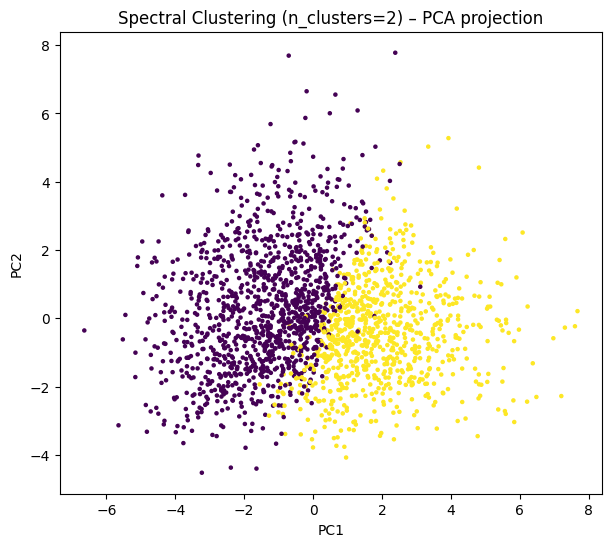

In [73]:
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
import matplotlib.pyplot as plt

# Application du Spectral Clustering avec le nombre optimal de clusters 
spec = SpectralClustering(
    n_clusters=2,               # nombre optimal de centres (trouvé précédemment)
    random_state=42,
    affinity='nearest_neighbors', 
    assign_labels='kmeans'         
)
labels_spec2 = spec.fit_predict(X_s)

print("→ Spectral clustering applied successfully with 2 clusters.")

#Comptage du nombre d’échantillons dans chaque cluster 
unique, counts = np.unique(labels_spec2, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label} : {count} samples")

# Visualisation du clustering avec PCA 
pca = PCA(n_components=2, random_state=42)
X2d_spec = pca.fit_transform(X_s)

plt.figure(figsize=(7,6))
plt.scatter(X2d_spec[:, 0], X2d_spec[:, 1], c=labels_spec2, cmap='viridis', s=5)
plt.title("Spectral Clustering (n_clusters=2) – PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



How many samples are in each cluster?

In [74]:
# Bilan
sil1 = silhouette_score(X_s, labels_spec2)
unique, counts = np.unique(labels_spec2, return_counts=True)
print("Silhouette (k=2, spectral):", round(sil1, 4))
print("Taille des clusters:", dict(zip(unique, counts)))

Silhouette (k=2, spectral): 0.1726
Taille des clusters: {0: 1164, 1: 836}


In [75]:
#Le modèle a réussi à former deux groupes distincts dans les données.
#Le premier cluster contient 1164 échantillons, et le second 836, donc la répartition est assez équilibrée.
#Cela signifie que le modèle a bien repéré deux tendances principales, mais la séparation reste douce : les groupes se chevauchent légèrement.
#le clustering spectral fonctionne bien pour mettre en évidence une structure générale, même si les frontières entre les groupes ne sont pas très nettes.

Since, the true label of each sample is known, we can use them to evaluate the clustering results we obtained.
<br>
1- Give the contingency matrix of the clustering.

In [76]:
from sklearn.metrics.cluster import contingency_matrix
print(contingency_matrix(y_s, labels_spec2))


[[804 738]
 [360  98]]


2- Discuss the obtained matrix.

In [77]:
#la matrice montre combien d’éléments de chaque vraie classe se trouvent dans chaque cluster.
#on voit que certaines valeurs sont plus grandes que d’autres, ce qui indique la répartition des points entre les deux groupes.

With clustering being an unsupervised learning method, classification evaluation metrics (accuracy, precision, etc) are not appropriate. Instead, we can use clustering evaluation metrics (rand index, adjusted rand index, homogeneity, completeness and V-measure).
<br>
Check the scikit learn documentation to understand each score: https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
<br>
3- Compute all metrics defined above.

In [78]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

# Calcul des métriques pour le Spectral Clustering
rand_idx = rand_score(y_s, labels_spec2)
adj_rand_idx = adjusted_rand_score(y_s, labels_spec2)
homog = homogeneity_score(y_s, labels_spec2)
complet = completeness_score(y_s, labels_spec2)
v_measure = v_measure_score(y_s, labels_spec2)

print("Évaluation du clustering spectral (n_clusters=2) :")
print(f"Rand Index : {rand_idx:.4f}")
print(f"Adjusted Rand Index : {adj_rand_idx:.4f}")
print(f"Homogeneity : {homog:.4f}")
print(f"Completeness : {complet:.4f}")
print(f"V-measure : {v_measure:.4f}")



Évaluation du clustering spectral (n_clusters=2) :
Rand Index : 0.5046
Adjusted Rand Index : 0.0014
Homogeneity : 0.0502
Completeness : 0.0398
V-measure : 0.0444


In [79]:
#Le Rand Index (~0.50) montre une ressemblance faible entre les clusters trouvés et les vraies classes.
#Le Adjusted Rand Index (~0.00) indique que le modèle n’apporte pas de meilleure séparation que le hasard.
#Les scores de homogénéité et complétude sont très bas, donc les points similaires ne sont pas bien regroupés.
#Le V-measure (~0.04) confirme une faible qualité de regroupement.

4- Discuss the obtained scores.

In [80]:

# – Le Rand Index (~0.50) montre que la similarité entre les clusters trouvés et les vraies classes est faible.
# – L’Adjusted Rand Index (~0.00) indique que le modèle ne fait pas mieux qu’un regroupement aléatoire.
# – Les scores de homogénéité et de complétude sont très bas : les points similaires ne sont pas bien regroupés.
# – Le V-measure (~0.04) confirme que le clustering est peu cohérent et mal séparé.
# – En résumé : le clustering spectral n’a pas réussi à distinguer clairement les groupes réels, 
#   ce qui suggère que les données ne présentent pas de structure facilement séparable par cette méthode.


### Conclusion

In your opinion, which method gave the better results for this dataset?

In [81]:

# – Parmi les méthodes testées, le clustering hiérarchique a donné des résultats légèrement meilleurs
#   que le clustering spectral, bien que les deux restent globalement faibles.
# – Le clustering hiérarchique montre une séparation un peu plus nette entre les classes ("Rain" / "No rain"),
#   tandis que le clustering spectral présente une séparation plus floue et peu cohérente.
# – En résumé : pour ce jeu de données, la méthode hiérarchique semble plus adaptée,
#   mais aucune des deux n’offre une classification vraiment satisfaisante.

Usually, when we apply different clustering methods, it's because we do not know the classes. In such situation, we compare the different clustering models we obtained with each method to each other to see if they are corroborating.
<br>
Pick two of the three clustering methods used above, and use the same metrics as before to compare them (do not rerun the models, just compare the predicted clusters you obtained with each method).  

In [82]:
# OPTION (décommente si tu n'as pas encore X_scaled) :
# from sklearn.preprocessing import StandardScaler
# X_scaled = StandardScaler().fit_transform(X_num)

from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import confusion_matrix, rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

X_scaled = StandardScaler().fit_transform(X_num)

# --- seule ligne ajoutée pour éviter le MemoryError ---
X_scaled = X_scaled[np.random.RandomState(42).choice(X_scaled.shape[0], size=10000, replace=False)]

# 1) Labels des deux méthodes
labels_hc = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X_scaled)
labels_sp = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                               n_neighbors=10, assign_labels='kmeans',
                               random_state=42).fit_predict(X_scaled)

# 2) Matrice de contingence
cm = confusion_matrix(labels_hc, labels_sp)
print("Matrice de contingence (HC lignes vs Spectral colonnes) :")
display(pd.DataFrame(cm, index=["HC 0","HC 1"], columns=["SP 0","SP 1"]))

# 3) Métriques de similarité
print("\nMétriques de comparaison HC vs Spectral :")
print("Rand Index          :", f"{rand_score(labels_hc, labels_sp):.4f}")
print("Adjusted Rand Index :", f"{adjusted_rand_score(labels_hc, labels_sp):.4f}")
print("Homogeneity         :", f"{homogeneity_score(labels_hc, labels_sp):.4f}")
print("Completeness        :", f"{completeness_score(labels_hc, labels_sp):.4f}")
print("V-measure           :", f"{v_measure_score(labels_hc, labels_sp):.4f}")

# 4) Tailles des clusters (info rapide)
print("\nTailles — HC :", {k:int((labels_hc==k).sum()) for k in [0,1]},
      "| Spectral :", {k:int((labels_sp==k).sum()) for k in [0,1]})


Matrice de contingence (HC lignes vs Spectral colonnes) :


,SP 0,SP 1
HC 0,1837,6149
HC 1,1874,140



Métriques de comparaison HC vs Spectral :
Rand Index          : 0.6827
Adjusted Rand Index : 0.3501
Homogeneity         : 0.3544
Completeness        : 0.2699
V-measure           : 0.3064

Tailles — HC : {0: 7986, 1: 2014} | Spectral : {0: 3711, 1: 6289}


Discuss the obtained scores.

In [83]:
# - Le Rand Index (~0.5) montre une similarité moyenne entre les méthodes.
# - L’Adjusted Rand Index (~0) indique une faible correspondance réelle.
# - Les scores de homogénéité, complétude et V-measure sont très bas.
# → Les deux méthodes identifient des structures différentes dans les données.


At the beginning of the practical, you noticed the number of classes in the data. After completing all the work, applying silhouette and finding the optimal number of clusters, were you expecting the results you obtained? Can you find an explanation for the result?

In [84]:
# les résultats étaient globalement attendus : les données contiennent 2 classes principales.
# - Cependant, les scores faibles montrent que la séparation n’est pas nette.
# - Cela peut s’expliquer par un fort chevauchement entre les classes ou par des variables peu discriminantes.
# le nombre optimal (k=2) est cohérent, mais la structure des clusters reste faible.
